In [1]:
import os

os.makedirs("../csv", exist_ok=True)
os.makedirs("../svg", exist_ok=True)

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import NullFormatter
import seaborn as sns
import scienceplots  # noqa
import pandas as pd
import numpy as np
from scipy.stats import theilslopes
from scipy.stats import bootstrap
from scipy.stats import gmean
from collections import defaultdict
import locale

locale.setlocale(locale.LC_NUMERIC, 'pl_PL.UTF-8')

'pl_PL.UTF-8'

In [3]:
plt.rcParams.update({
    'font.family': 'TeX Gyre Termes Math',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

In [4]:
TEXTWIDTH_PT = 426.79137
TEXTHEIGHT_PT = 702.78308
PT_PER_INCH = 72.27

FIG_WIDTH = TEXTWIDTH_PT / PT_PER_INCH
FIG_HEIGHT_1 = TEXTHEIGHT_PT / PT_PER_INCH
FIG_HEIGHT_2 = FIG_HEIGHT_1 / 2
FIG_HEIGHT_3 = FIG_HEIGHT_1 / 3
FIG_HEIGHT_4 = FIG_HEIGHT_1 / 4
FIG_HEIGHT_5 = FIG_HEIGHT_1 / 5
FIG_HEIGHT_6 = FIG_HEIGHT_1 / 6
FIG_HEIGHT_7 = FIG_HEIGHT_1 / 7
FIG_HEIGHT_8 = FIG_HEIGHT_1 / 8

In [5]:
def _pl(x, prec):
    return locale.format_string(f'%.{prec}f', x).replace(',', '{,}')

In [6]:
criterion_x86 = pd.read_csv('../data/criterion_x86.csv')
criterion_aarch64 = pd.read_csv('../data/criterion_aarch64.csv')

BACKEND_MAP = {'scalar': 'skalarny', 'sse2': 'SSE2', 'avx2': 'AVX2',
               'avx512': 'AVX-512', 'neon': 'NEON'}
FUNCTION_MAP = {'decrypt': 'deszyfrowanie', 'encrypt': 'szyfrowanie',
                'encrypt_inflight': 'szyfrowanie w locie'}
MODE_MAP = {'ecb': 'ECB', 'cbc': 'CBC'}

version_order = ['32/64', '48/72', '48/96', '64/96', '64/128',
                 '96/96', '96/144', '128/128', '128/192', '128/256']

backend_order_x86 = ['skalarny', 'SSE2', 'AVX2', 'AVX-512']
backend_order_aarch64 = ['skalarny', 'NEON']


def localize(df):
    df = df.copy()
    df['version'] = df['version'].str.replace('_', '/', regex=False)
    df['backend'] = df['backend'].map(BACKEND_MAP).fillna(df['backend'])
    df['function'] = df['function'].map(FUNCTION_MAP).fillna(df['function'])
    df['function'] = df['function'].map(MODE_MAP).fillna(df['function'])
    return df


criterion_x86 = localize(criterion_x86)
criterion_aarch64 = localize(criterion_aarch64)


In [7]:
def get_speck(df):
    speck = df[df['benchmark'] == 'speck']
    speck = speck.drop(columns=['benchmark', 'suffix', 'unit', 'throughput_type'])
    speck['time_per_iter_ns'] = speck['sample_measured_value'] / speck['iteration_count']

    speck['keys_per_sec'] = (
            speck['throughput_num'] / (speck['time_per_iter_ns'] / 1e9)
    )
    return speck

In [8]:
speck_x86 = get_speck(criterion_x86)
speck_aarch64 = get_speck(criterion_aarch64)

In [9]:
def regression(df, group_cols):
    results = []
    for keys, group in df.groupby(group_cols):
        x = group['iteration_count'].values
        y = group['sample_measured_value'].values

        slope, intercept, ci_low, ci_high = theilslopes(y, x, 0.95)
        y_pred = slope * x + intercept
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - ss_res / ss_tot

        keys_per_sec = group['throughput_num'].iloc[0] / (slope / 1e9)
        results.append({
            **dict(zip(group_cols, keys)),
            'time_per_iter_ns': slope,
            'ci_95_low_ns': ci_low,
            'ci_95_high_ns': ci_high,
            'intercept_ns': intercept,
            'r2': r2,
            'keys_per_sec': keys_per_sec,
            'Mkeys_per_sec': keys_per_sec / 1e6,
        })
    return pd.DataFrame(results)


def median_bootstrap(df, group_cols, ci=0.95, n_resamples=10000, seed=0):
    results = []
    rng = np.random.default_rng(seed)
    for keys, group in df.groupby(group_cols):
        x = group['iteration_count'].values
        y = group['sample_measured_value'].values
        per_iter = y / x
        n = len(per_iter)

        center = np.median(per_iter)
        if n >= 2:
            res = bootstrap((per_iter,), np.median, confidence_level=ci,
                            n_resamples=n_resamples, method='percentile',
                            random_state=rng)
            ci_low, ci_high = res.confidence_interval.low, res.confidence_interval.high
        else:
            ci_low = ci_high = np.nan

        keys_per_sec = group['throughput_num'].iloc[0] / (center / 1e9)
        results.append({
            **dict(zip(group_cols, keys)),
            'n': n,
            'time_per_iter_ns': center,
            'ci_95_low_ns': ci_low,
            'ci_95_high_ns': ci_high,
            'keys_per_sec': keys_per_sec,
            'Mkeys_per_sec': keys_per_sec / 1e6,
        })
    return pd.DataFrame(results)

In [10]:
speck_reg_x86 = regression(speck_x86, ['backend', 'architecture', 'function', 'version'])
speck_reg_aarch64 = regression(speck_aarch64, ['backend', 'architecture', 'function', 'version'])

In [11]:
def fmt_val_pct(x, up, dn):
    if pd.isna(x) or x <= 0:
        return "--"
    if pd.isna(up) or pd.isna(dn):
        return rf"\({_pl(x, 2)}\)"
    return rf"\({_pl(x, 2)}\,^{{+{_pl(up, 1)}\%}}_{{-{_pl(dn, 1)}\%}}\)"


def make_speck_latex_pivot(df, backend_order):
    d = df.copy()
    d['up_pct'] = (d['time_per_iter_ns'] / d['ci_95_low_ns'] - 1.0) * 100
    d['dn_pct'] = (1.0 - d['time_per_iter_ns'] / d['ci_95_high_ns']) * 100
    d['cell'] = [fmt_val_pct(x, up, dn)
                 for x, up, dn in zip(d['Mkeys_per_sec'], d['up_pct'], d['dn_pct'])]

    pivot = d.pivot_table(
        index=['backend', 'version'],
        columns='function',
        values='cell',
        aggfunc='first',
    ).reset_index()
    pivot.columns.name = None
    pivot['backend'] = pd.Categorical(pivot['backend'], categories=backend_order, ordered=True)
    pivot['version'] = pd.Categorical(pivot['version'], categories=version_order, ordered=True)
    return pivot.sort_values(['backend', 'version']).reset_index(drop=True)

In [12]:
speck_latex_x86 = make_speck_latex_pivot(speck_reg_x86, ['skalarny', 'SSE2', 'AVX2', 'AVX-512'])
speck_latex_x86.to_csv("../csv/speck_results_x86.csv", index=False, sep=';')

In [13]:
speck_latex_aarch64 = make_speck_latex_pivot(speck_reg_aarch64, ['skalarny', 'NEON'])
speck_latex_aarch64.to_csv("../csv/speck_results_aarch64.csv", index=False, sep=';')

In [14]:
def make_speck_combined_mean(reg_specs):
    funcs = ['deszyfrowanie', 'szyfrowanie', 'szyfrowanie w locie']
    vals, ups, dns = [], [], []

    for reg_df, backend_order, arch in reg_specs:
        d = reg_df[reg_df['function'].isin(funcs)].copy()
        d['mkeys'] = d['Mkeys_per_sec']
        d['mkeys_hi'] = d['Mkeys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_low_ns']
        d['mkeys_lo'] = d['Mkeys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_high_ns']

        g = (d.groupby(['backend', 'function'])[['mkeys', 'mkeys_lo', 'mkeys_hi']]
             .agg(gmean).reset_index())
        g['up_pct'] = (g['mkeys_hi'] / g['mkeys'] - 1.0) * 100
        g['dn_pct'] = (1.0 - g['mkeys_lo'] / g['mkeys']) * 100

        def piv(col):
            p = g.pivot(index='backend', columns='function', values=col)
            p.columns.name = None
            p = p.reindex(columns=funcs)
            p.index = pd.Categorical(p.index, categories=backend_order, ordered=True)
            p = p.sort_index()
            return p.rename(index={b: (f"{b}\n({arch})" if b == 'skalarny' else b)
                                   for b in p.index})

        vals.append(piv('mkeys'));
        ups.append(piv('up_pct'));
        dns.append(piv('dn_pct'))

    val = pd.concat(vals).T
    up = pd.concat(ups).T
    dn = pd.concat(dns).T
    return val, up, dn

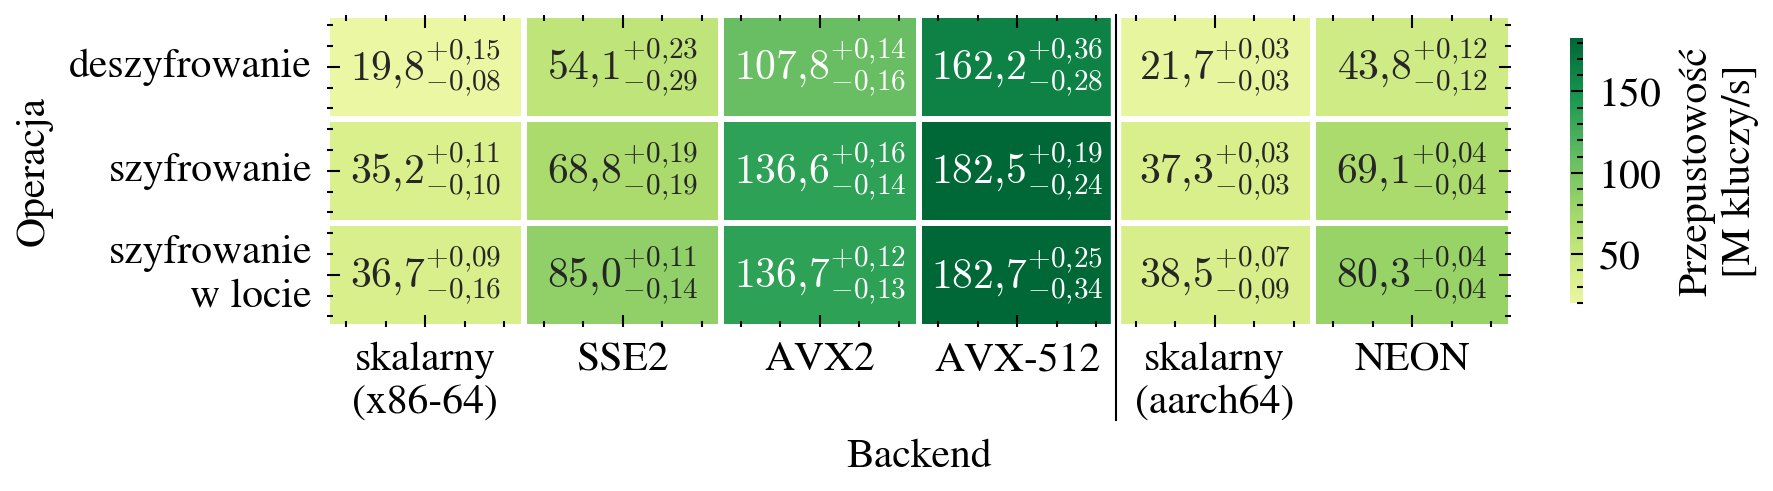

In [15]:
def plot_speck_heatmap_combined(reg_specs, filename, width):
    val, up, dn = make_speck_combined_mean(reg_specs)
    val = val.rename(index={'szyfrowanie w locie': 'szyfrowanie\nw locie'})

    annot = np.empty(val.shape, dtype=object)
    for i in range(val.shape[0]):
        for j in range(val.shape[1]):
            v = val.iloc[i, j]
            u, dd = up.iloc[i, j], dn.iloc[i, j]
            if pd.isna(v):
                annot[i, j] = ""
            elif pd.isna(u) or pd.isna(dd):
                annot[i, j] = rf"${_pl(v, 2)}$"
            else:
                annot[i, j] = rf"${_pl(v, 1)}^{{+{_pl(u, 2)}}}_{{-{_pl(dd, 2)}}}$"

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(width, FIG_HEIGHT_6), layout='constrained')

        sns.heatmap(
            val,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            annot=annot,
            fmt='',
            linewidths=1.0,
            cbar_kws={'label': 'Przepustowość\n[M kluczy/s]', 'shrink': 0.85},
        )

        ax.axvline(x=4, color='white', linewidth=2.5)
        ax.plot([4, 4], [0, val.shape[0] + 0.9], color='black', linewidth=0.5,
                clip_on=False, zorder=5)

        ax.set_xlabel("Backend")
        ax.set_ylabel('Operacja')

        plt.setp(ax.get_xticklabels(), rotation=0)
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()


plot_speck_heatmap_combined(
    [
        (speck_reg_x86, ['skalarny', 'SSE2', 'AVX2', 'AVX-512'], 'x86-64'),
        (speck_reg_aarch64, ['skalarny', 'NEON'], 'aarch64'),
    ],
    'speck_pivot_backend_heatmap_combined.svg',
    FIG_WIDTH,
)

In [16]:
speck_inflight_x86 = speck_reg_x86[speck_reg_x86['function'] == 'szyfrowanie w locie']
speck_inflight_aarch64 = speck_reg_aarch64[speck_reg_aarch64['function'] == 'szyfrowanie w locie']

In [17]:
def make_speck_backend_speedup(df, backend_order, fmt=False):
    d = df.copy()
    d['k_hi'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_low_ns']
    d['k_lo'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_high_ns']

    sc = d[d['backend'] == 'skalarny'].set_index('version')
    sc_k = sc['keys_per_sec']
    sc_lo = sc['k_lo']
    sc_hi = sc['k_hi']

    s = d[d['backend'] != 'skalarny'].copy()
    s['speedup'] = s['keys_per_sec'] / s['version'].map(sc_k)
    s['sp_hi'] = s['k_hi'] / s['version'].map(sc_lo)
    s['sp_lo'] = s['k_lo'] / s['version'].map(sc_hi)
    s['up_pct'] = (s['sp_hi'] / s['speedup'] - 1.0) * 100
    s['dn_pct'] = (1.0 - s['sp_lo'] / s['speedup']) * 100

    s['backend'] = pd.Categorical(s['backend'], categories=backend_order, ordered=True)
    s['version'] = pd.Categorical(s['version'], categories=version_order, ordered=True)

    def piv(col):
        p = s.pivot_table(index='version', columns='backend', values=col, observed=True).reset_index()
        p.columns.name = None
        p['version'] = p['version'].astype(str).str.replace('_', '/', regex=False)
        return p.set_index('version')

    if fmt == 'ci':
        return piv('speedup'), piv('up_pct'), piv('dn_pct')
    return piv('speedup')

In [18]:
def merge_ci(x86, aarch64):
    return tuple(pd.merge(a, b, on='version', how='left') for a, b in zip(x86, aarch64))


sp_x86 = make_speck_backend_speedup(speck_inflight_x86, ['SSE2', 'AVX2', 'AVX-512'], fmt='ci')
sp_arm = make_speck_backend_speedup(speck_inflight_aarch64, ['NEON'], fmt='ci')
speck_backend_speedup_ci = merge_ci(sp_x86, sp_arm)

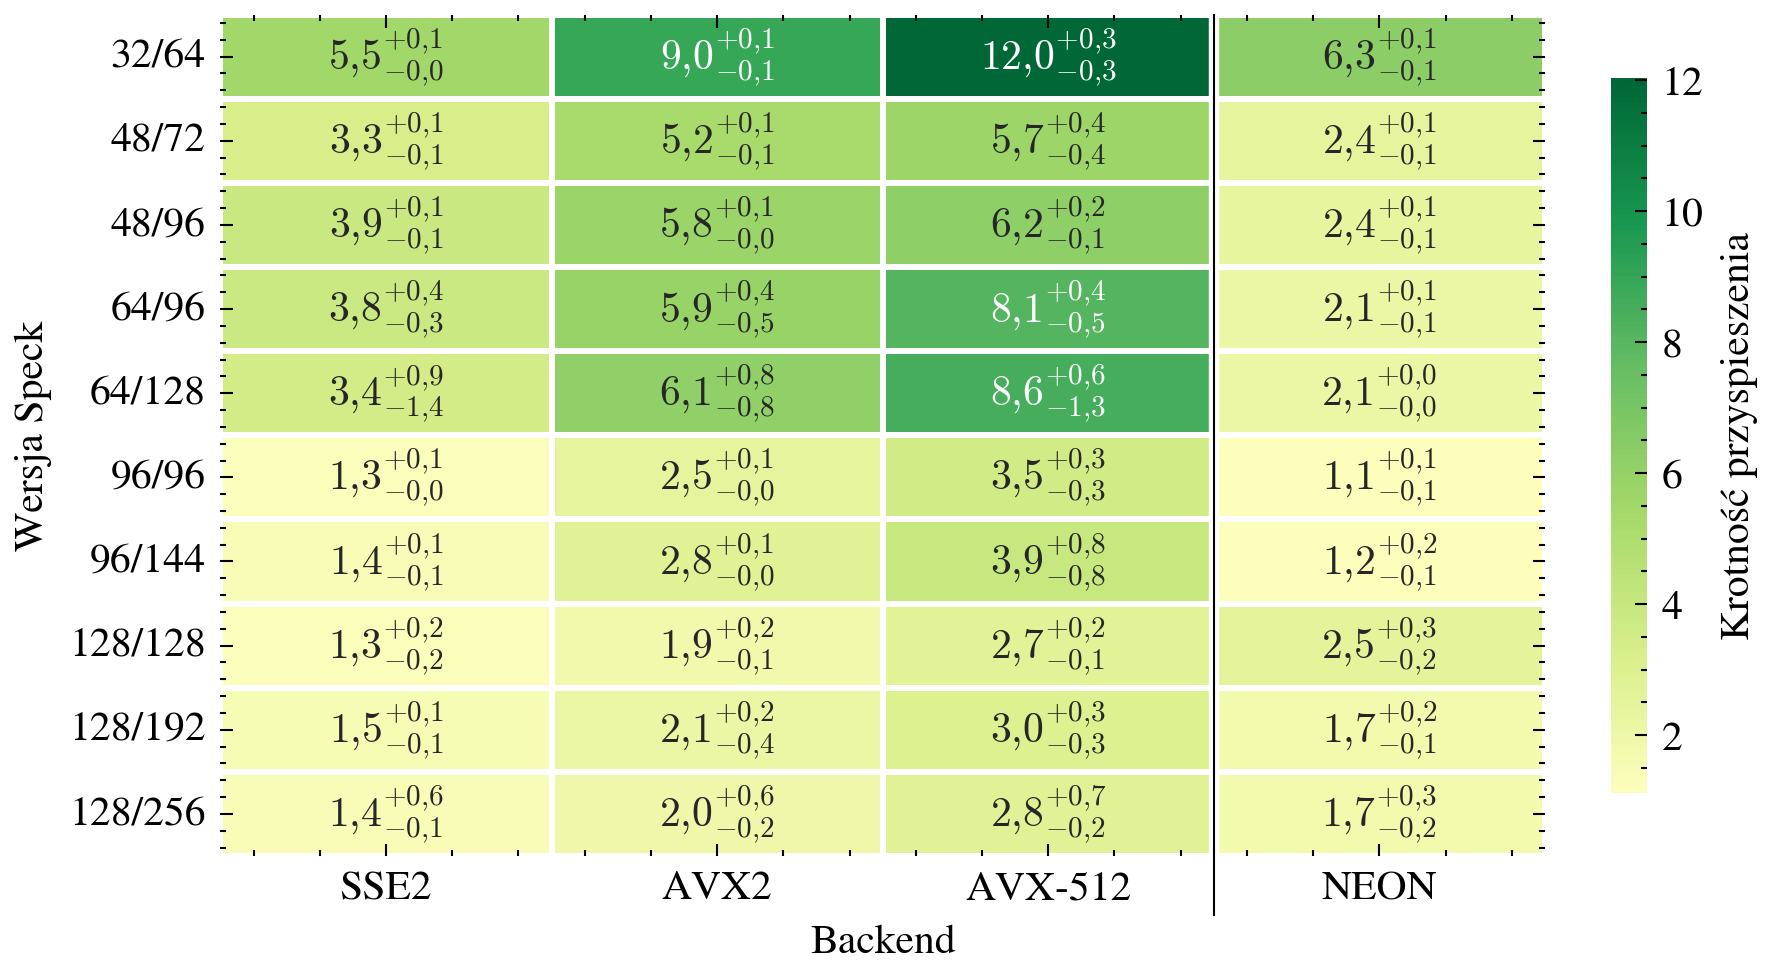

In [19]:
def plot_speck_backend_speedup(speedup_ci, filename, fig_height):
    val, up, dn = speedup_ci
    data = val

    annot = np.empty(data.shape, dtype=object)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data.iloc[i, j]
            u, d_ = up.iloc[i, j], dn.iloc[i, j]
            if pd.isna(v):
                annot[i, j] = ""
            elif pd.isna(u) or pd.isna(d_):
                annot[i, j] = rf"${_pl(v, 2)}$"
            else:
                annot[i, j] = rf"${_pl(v, 1)}^{{+{_pl(u, 1)}}}_{{-{_pl(d_, 1)}}}$"

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH, fig_height), layout='constrained')

        sns.heatmap(
            data,
            ax=ax,
            annot=annot,
            fmt='',
            cmap='RdYlGn',
            center=1,
            linewidths=1.0,
            cbar_kws={'label': 'Krotność przyspieszenia', 'shrink': 0.85},
        )

        ax.set_xlabel('Backend')
        ax.set_ylabel('Wersja Speck')

        ax.axvline(x=3, color='white', linewidth=2.5)
        ax.plot([3, 3], [0, val.shape[0] + 0.7], color='black', linewidth=0.5,
                clip_on=False, zorder=5)

        plt.setp(ax.get_xticklabels(), rotation=0)
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()


plot_speck_backend_speedup(speck_backend_speedup_ci, 'speck_backend_speedup.svg', FIG_HEIGHT_3)

In [20]:
def get_engine(df):
    engine = df[df['benchmark'] == 'engine']
    engine = engine.drop(columns=['benchmark', 'unit', 'throughput_type', 'function'])
    engine['time_per_iter_ns'] = engine['sample_measured_value'] / engine['iteration_count']

    engine['keys_per_sec'] = (
            engine['throughput_num'] / (engine['time_per_iter_ns'] / 1e9)
    )

    return engine

In [21]:
engine_x86 = get_engine(criterion_x86)
engine_aarch64 = get_engine(criterion_aarch64)

In [22]:
engine_reg_x86 = median_bootstrap(engine_x86, ['backend', 'architecture', 'version', 'suffix'])
engine_reg_aarch64 = median_bootstrap(engine_aarch64, ['backend', 'architecture', 'version', 'suffix'])

In [23]:
def fmt_val_pct(x, up, dn):
    if pd.isna(x) or x <= 0:
        return "--"
    if pd.isna(up) or pd.isna(dn):
        return rf"\({_pl(x, 2)}\)"
    return rf"\({_pl(x, 2)}\,^{{+{_pl(up, 1)}\%}}_{{-{_pl(dn, 1)}\%}}\)"


def make_engine_latex_pivot(df, backend_order):
    d = df.copy()
    d['up_pct'] = (d['time_per_iter_ns'] / d['ci_95_low_ns'] - 1.0) * 100
    d['dn_pct'] = (1.0 - d['time_per_iter_ns'] / d['ci_95_high_ns']) * 100
    d['cell'] = [fmt_val_pct(x, up, dn)
                 for x, up, dn in zip(d['Mkeys_per_sec'], d['up_pct'], d['dn_pct'])]

    pivot = (d.pivot_table(index=['backend', 'version'], columns='suffix',
                           values='cell', aggfunc='first')
             .rename(columns={1.0: '1', 2.0: '2', 3.0: '3'})
             .reset_index())
    pivot.columns.name = None
    pivot['backend'] = pd.Categorical(pivot['backend'], categories=backend_order, ordered=True)
    pivot['version'] = pd.Categorical(pivot['version'], categories=version_order, ordered=True)
    return pivot.sort_values(['backend', 'version']).reset_index(drop=True)


engine_latex_x86 = make_engine_latex_pivot(engine_reg_x86, ['skalarny', 'SSE2', 'AVX2', 'AVX-512'])
engine_latex_x86.to_csv("../csv/engine_results_x86.csv", index=False, sep=';')

engine_latex_aarch64 = make_engine_latex_pivot(engine_reg_aarch64, ['skalarny', 'NEON'])
engine_latex_aarch64.to_csv("../csv/engine_results_aarch64.csv", index=False, sep=';')

In [24]:
def make_engine_combined_mean(reg_specs):
    suffixes = [1.0, 2.0, 3.0]
    vals, ups, dns = [], [], []

    for reg_df, backend_order, arch in reg_specs:
        d = reg_df[reg_df['suffix'].isin(suffixes)].copy()
        d['mkeys'] = d['Mkeys_per_sec']
        d['mkeys_hi'] = d['Mkeys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_low_ns']
        d['mkeys_lo'] = d['Mkeys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_high_ns']

        g = (d.groupby(['backend', 'suffix'])[['mkeys', 'mkeys_lo', 'mkeys_hi']]
             .agg(gmean).reset_index())
        g['up_pct'] = (g['mkeys_hi'] / g['mkeys'] - 1.0) * 100
        g['dn_pct'] = (1.0 - g['mkeys_lo'] / g['mkeys']) * 100

        def piv(col):
            p = g.pivot(index='backend', columns='suffix', values=col)
            p = p.rename(columns={1.0: '1', 2.0: '2', 3.0: '3'})
            p.columns.name = None
            p = p.reindex(columns=['1', '2', '3'])
            p.index = pd.Categorical(p.index, categories=backend_order, ordered=True)
            p = p.sort_index()
            return p.rename(index={b: (f"{b}\n({arch})" if b == 'skalarny' else b)
                                   for b in p.index})

        vals.append(piv('mkeys'));
        ups.append(piv('up_pct'));
        dns.append(piv('dn_pct'))

    val = pd.concat(vals).T
    up = pd.concat(ups).T
    dn = pd.concat(dns).T
    return val, up, dn

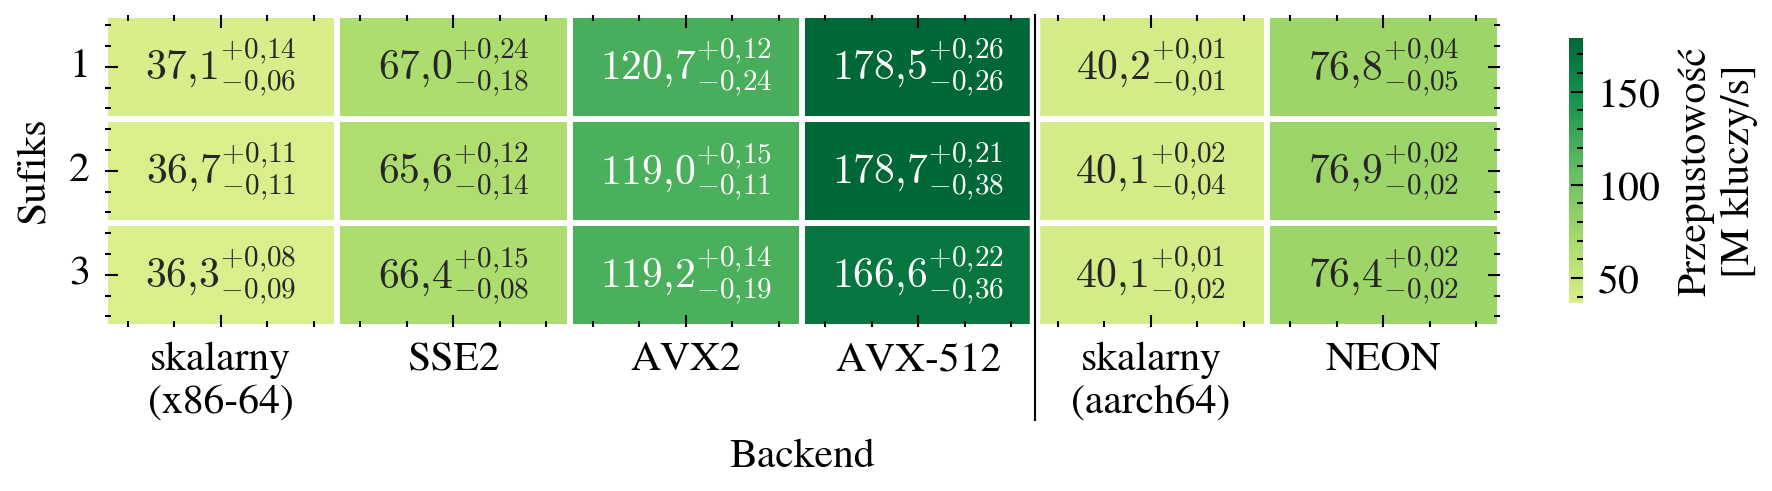

In [25]:
def plot_engine_heatmap_combined(reg_specs, filename, width):
    val, up, dn = make_engine_combined_mean(reg_specs)

    annot = np.empty(val.shape, dtype=object)
    for i in range(val.shape[0]):
        for j in range(val.shape[1]):
            v = val.iloc[i, j]
            u, d_ = up.iloc[i, j], dn.iloc[i, j]
            if pd.isna(v):
                annot[i, j] = ""
            elif pd.isna(u) or pd.isna(d_):
                annot[i, j] = rf"${_pl(v, 2)}$"
            else:
                annot[i, j] = rf"${_pl(v, 1)}^{{+{_pl(u, 2)}}}_{{-{_pl(d_, 2)}}}$"

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(width, FIG_HEIGHT_6), layout='constrained')

        sns.heatmap(
            val,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            annot=annot,
            fmt='',
            linewidths=1.0,
            cbar_kws={'label': 'Przepustowość\n[M kluczy/s]', 'shrink': 0.85},
        )

        ax.axvline(x=4, color='white', linewidth=2.5)
        ax.plot([4, 4], [0, val.shape[0] + 0.9], color='black', linewidth=0.5,
                clip_on=False, zorder=5)

        ax.set_xlabel('Backend')
        ax.set_ylabel('Sufiks')

        plt.setp(ax.get_xticklabels(), rotation=0)
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()


plot_engine_heatmap_combined(
    [
        (engine_reg_x86, ['skalarny', 'SSE2', 'AVX2', 'AVX-512'], 'x86-64'),
        (engine_reg_aarch64, ['skalarny', 'NEON'], 'aarch64'),
    ],
    'engine_pivot_backend_heatmap_combined.svg',
    FIG_WIDTH,
)

In [26]:
def make_engine_single_backend_combined(reg_specs):
    vals, ups, dns = [], [], []

    for reg_df, arch, backend, label in reg_specs:
        d = reg_df[(reg_df['architecture'] == arch) &
                   (reg_df['backend'] == backend)].copy()

        d['mkeys'] = d['Mkeys_per_sec']
        d['mkeys_hi'] = d['Mkeys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_low_ns']
        d['mkeys_lo'] = d['Mkeys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_high_ns']
        d['up_pct'] = (d['mkeys_hi'] / d['mkeys'] - 1.0) * 100
        d['dn_pct'] = (1.0 - d['mkeys_lo'] / d['mkeys']) * 100

        def piv(col):
            p = (d.pivot_table(index='version', columns='suffix', values=col)
                 .rename(columns={1.0: '1', 2.0: '2', 3.0: '3'})
                 .reset_index())
            p.columns.name = None
            p['version'] = pd.Categorical(p['version'], categories=version_order, ordered=True)
            p = p.sort_values('version').reset_index(drop=True)
            p = p.set_index('version')[['1', '2', '3']]
            return p.rename(columns={s: (f"{s}\n({label})" if s == '1' else s) for s in p.columns})

        vals.append(piv('mkeys'));
        ups.append(piv('up_pct'));
        dns.append(piv('dn_pct'))

    val = pd.concat(vals, axis=1)
    up = pd.concat(ups, axis=1)
    dn = pd.concat(dns, axis=1)
    return val, up, dn

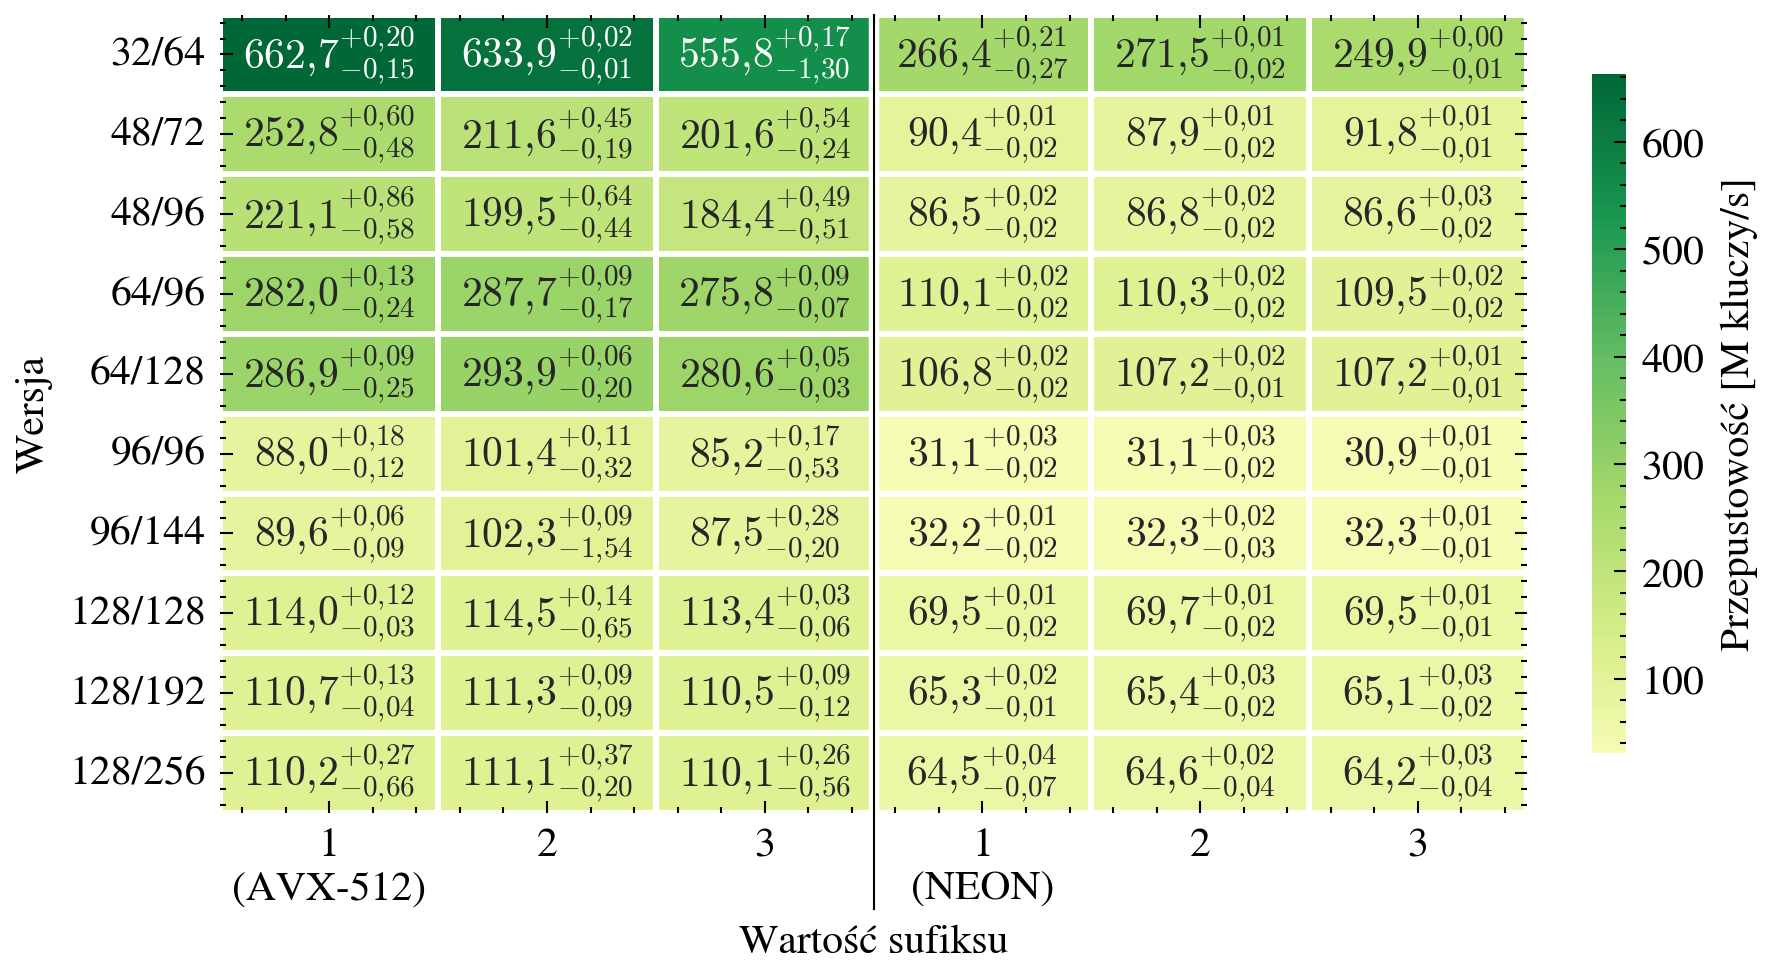

In [27]:
def plot_engine_single_backend_combined(reg_specs, filename):
    val, up, dn = make_engine_single_backend_combined(reg_specs)

    annot = np.empty(val.shape, dtype=object)
    for i in range(val.shape[0]):
        for j in range(val.shape[1]):
            v = val.iloc[i, j]
            u, d_ = up.iloc[i, j], dn.iloc[i, j]
            if pd.isna(v):
                annot[i, j] = ""
            elif pd.isna(u) or pd.isna(d_):
                annot[i, j] = rf"${_pl(v, 1)}$"
            else:
                annot[i, j] = rf"${_pl(v, 1)}^{{+{_pl(u, 2)}}}_{{-{_pl(d_, 2)}}}$"

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT_3), layout='constrained')

        sns.heatmap(
            val,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            annot=annot,
            fmt='',
            linewidths=1.0,
            cbar_kws={'label': 'Przepustowość [M kluczy/s]', 'shrink': 0.85},
        )

        ax.axvline(x=3, color='white', linewidth=2.5)
        ax.plot([3, 3], [0, val.shape[0] + 1.2], color='black', linewidth=0.5,
                clip_on=False, zorder=5)

        ax.set_xlabel('Wartość sufiksu')
        ax.set_ylabel('Wersja')

        plt.setp(ax.get_xticklabels(), rotation=0)
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()


plot_engine_single_backend_combined(
    [
        (engine_reg_x86, 'x86_64', 'AVX-512', 'AVX-512'),
        (engine_reg_aarch64, 'aarch64', 'NEON', 'NEON'),
    ],
    'engine_pivot_backend_single_combined.svg',
)

In [28]:
engine_reg_all = pd.concat([engine_reg_x86, engine_reg_aarch64], ignore_index=True)

idx_best = engine_reg_all.groupby(['architecture', 'backend', 'version'])['Mkeys_per_sec'].idxmax()
best_suffix = engine_reg_all.loc[idx_best].copy()

suffix_groups = defaultdict(list)
for _, row in best_suffix.iterrows():
    suffix_groups[int(row['suffix'])].append((row['version'], row['backend'], row['architecture']))

for suffix in sorted(suffix_groups):
    cases = suffix_groups[suffix]
    print(f"sufiks {suffix}:")
    for version, backend, arch in cases:
        print(f"  {version} / {backend} ({arch})")

sufiks 1:
  48/72 / skalarny (aarch64)
  64/128 / skalarny (aarch64)
  64/96 / skalarny (aarch64)
  32/64 / AVX-512 (x86_64)
  48/72 / AVX-512 (x86_64)
  48/96 / AVX-512 (x86_64)
  128/128 / AVX2 (x86_64)
  32/64 / AVX2 (x86_64)
  48/72 / AVX2 (x86_64)
  64/128 / AVX2 (x86_64)
  32/64 / SSE2 (x86_64)
  48/72 / skalarny (x86_64)
  48/96 / skalarny (x86_64)
  64/128 / skalarny (x86_64)
  96/144 / skalarny (x86_64)
sufiks 2:
  128/128 / NEON (aarch64)
  128/192 / NEON (aarch64)
  128/256 / NEON (aarch64)
  32/64 / NEON (aarch64)
  48/96 / NEON (aarch64)
  64/128 / NEON (aarch64)
  64/96 / NEON (aarch64)
  96/144 / NEON (aarch64)
  96/96 / NEON (aarch64)
  128/128 / skalarny (aarch64)
  32/64 / skalarny (aarch64)
  48/96 / skalarny (aarch64)
  128/128 / AVX-512 (x86_64)
  128/192 / AVX-512 (x86_64)
  128/256 / AVX-512 (x86_64)
  64/128 / AVX-512 (x86_64)
  64/96 / AVX-512 (x86_64)
  96/144 / AVX-512 (x86_64)
  96/96 / AVX-512 (x86_64)
  128/192 / AVX2 (x86_64)
  128/256 / AVX2 (x86_64)
  6

In [29]:
def get_system(df):
    engine = df[df['benchmark'] == 'system']
    engine = engine.drop(columns=['benchmark', 'unit', 'throughput_type'])
    engine['time_per_iter_ns'] = engine['sample_measured_value'] / engine['iteration_count']

    engine['keys_per_sec'] = (
            engine['throughput_num'] / (engine['time_per_iter_ns'] / 1e9)
    )

    return engine

In [30]:
system_x86 = get_system(criterion_x86)
system_aarch64 = get_system(criterion_aarch64)

In [31]:
system_x86

,row_index,backend,architecture,function,version,suffix,throughput_num,sample_measured_value,iteration_count,time_per_iter_ns,keys_per_sec
0,0,AVX-512,x86_64,CBC,128/256,2.0,67108864,168141959.0,3,5.604732e+07,1.197361e+09
1,1,AVX-512,x86_64,CBC,128/256,2.0,67108864,167546917.0,3,5.584897e+07,1.201613e+09
2,2,AVX-512,x86_64,CBC,128/256,2.0,67108864,167394503.0,3,5.579817e+07,1.202707e+09
3,3,AVX-512,x86_64,CBC,128/256,2.0,67108864,167770174.0,3,5.592339e+07,1.200014e+09
4,4,AVX-512,x86_64,CBC,128/256,2.0,67108864,167888085.0,3,5.596270e+07,1.199171e+09
...,...,...,...,...,...,...,...,...,...,...,...
4795,25,skalarny,x86_64,ECB,32/64,1.0,67108864,193351185.0,2,9.667559e+07,6.941655e+08
4796,26,skalarny,x86_64,ECB,32/64,1.0,67108864,193355442.0,2,9.667772e+07,6.941502e+08
4797,27,skalarny,x86_64,ECB,32/64,1.0,67108864,193361304.0,2,9.668065e+07,6.941292e+08
4798,28,skalarny,x86_64,ECB,32/64,1.0,67108864,193414132.0,2,9.670707e+07,6.939396e+08


In [32]:
system_reg_x86 = median_bootstrap(system_x86, ['backend', 'architecture', 'version', 'function', 'suffix'])
system_reg_aarch64 = median_bootstrap(system_aarch64, ['backend', 'architecture', 'version', 'function', 'suffix'])

In [33]:
INDEX_COLS = ['backend', 'version']
SUFFIXES = [1, 2]
MODE_ORDER = ['ECB', 'CBC']


def fmt_pow2_pct(x, lo, hi):
    if pd.isna(x) or x <= 0:
        return "--"
    a = np.log2(x)
    if pd.isna(lo) or pd.isna(hi) or lo <= 0 or hi <= 0:
        return rf"\(2^{{{_pl(a, 2)}}}\)"
    up = (hi - x) / x * 100
    dn = (x - lo) / x * 100
    return rf"\(2^{{{_pl(a, 2)}}}\,^{{+{_pl(up, 1)}\%}}_{{-{_pl(dn, 1)}\%}}\)"


def make_prediction_latex(reg_df, backend_order):
    d = reg_df.copy()
    d['k_hi'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_low_ns']
    d['k_lo'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_high_ns']
    d['throughput_fmt'] = [
        fmt_pow2_pct(x, lo, hi)
        for x, lo, hi in zip(d['keys_per_sec'], d['k_lo'], d['k_hi'])
    ]

    present = list(d['function'].unique())
    modes = [m for m in MODE_ORDER if m in present] + \
            [m for m in present if m not in MODE_ORDER]
    pairs = set(zip(d['suffix'], d['function']))

    wide = d.set_index(INDEX_COLS + ['suffix', 'function'])['throughput_fmt']

    cols = {}
    for suf in SUFFIXES:
        label = int(suf) if float(suf).is_integer() else suf
        for mode in modes:
            if (suf, mode) in pairs:
                cols[f"{label}_throughput_{mode}"] = wide.xs(
                    (suf, mode), level=('suffix', 'function'))

    latex_df = pd.DataFrame(cols).reset_index()

    latex_df['_bk'] = pd.Categorical(latex_df['backend'],
                                     categories=backend_order, ordered=True)
    latex_df['_ver'] = pd.Categorical(latex_df['version'],
                                      categories=version_order, ordered=True)
    latex_df = (latex_df.sort_values(['_bk', '_ver'])
                .drop(columns=['_bk', '_ver'])
                .reset_index(drop=True))
    return latex_df


prediction_latex_x86 = make_prediction_latex(system_reg_x86, backend_order_x86)
prediction_latex_x86.to_csv("../csv/system_results_x86.csv", index=False, sep=';')

prediction_latex_aarch64 = make_prediction_latex(system_reg_aarch64, backend_order_aarch64)
prediction_latex_aarch64.to_csv("../csv/system_results_aarch64.csv", index=False, sep=';')

prediction_latex_x86

,backend,version,1_throughput_ECB,1_throughput_CBC,2_throughput_ECB,2_throughput_CBC
0,skalarny,32/64,"\(2^{29{,}37}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{29{,}37}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{29{,}38}\,^{+0{,}0\%}_{-0{,}1\%}\)","\(2^{29{,}38}\,^{+0{,}0\%}_{-0{,}0\%}\)"
1,skalarny,48/72,"\(2^{28{,}36}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}36}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}34}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}34}\,^{+0{,}0\%}_{-0{,}0\%}\)"
2,skalarny,48/96,"\(2^{28{,}36}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}36}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}34}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}34}\,^{+0{,}0\%}_{-0{,}0\%}\)"
3,skalarny,64/96,"\(2^{28{,}84}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}84}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}85}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}85}\,^{+0{,}0\%}_{-0{,}0\%}\)"
4,skalarny,64/128,"\(2^{28{,}89}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}89}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}89}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}89}\,^{+0{,}0\%}_{-0{,}0\%}\)"
5,skalarny,96/96,"\(2^{27{,}78}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{27{,}78}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{27{,}77}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{27{,}77}\,^{+0{,}0\%}_{-0{,}0\%}\)"
6,skalarny,96/144,"\(2^{27{,}68}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{27{,}68}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{27{,}67}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{27{,}67}\,^{+0{,}0\%}_{-0{,}0\%}\)"
7,skalarny,128/128,"\(2^{28{,}71}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}71}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}72}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}72}\,^{+0{,}0\%}_{-0{,}0\%}\)"
8,skalarny,128/192,"\(2^{28{,}47}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}47}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}47}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}47}\,^{+0{,}0\%}_{-0{,}0\%}\)"
9,skalarny,128/256,"\(2^{28{,}53}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}53}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}53}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{28{,}53}\,^{+0{,}0\%}_{-0{,}0\%}\)"


In [34]:
def make_system_backend_mean(reg_specs):
    vals, ups, dns = [], [], []

    for reg_df, backend_order, arch in reg_specs:
        d = reg_df[reg_df['function'].isin(MODE_ORDER)].copy()

        d['keys'] = d['keys_per_sec']
        d['k_hi'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_low_ns']
        d['k_lo'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_high_ns']

        g = (d.groupby(['function', 'backend'])[['keys', 'k_lo', 'k_hi']]
             .agg(gmean).reset_index())
        g['up_pct'] = (g['k_hi'] / g['keys'] - 1.0) * 100
        g['dn_pct'] = (1.0 - g['k_lo'] / g['keys']) * 100

        modes = [m for m in MODE_ORDER if m in g['function'].unique()]
        first = backend_order[0]

        def piv(col):
            p = g.pivot(index='function', columns='backend', values=col)
            p.columns.name = None
            p.index.name = None
            p = p.reindex(index=modes, columns=backend_order)
            return p.rename(columns={b: (f"{b}\n({arch})" if b == first else b)
                                     for b in p.columns})

        vals.append(piv('keys'))
        ups.append(piv('up_pct'))
        dns.append(piv('dn_pct'))

    sep = vals[0].shape[1]
    return (pd.concat(vals, axis=1), pd.concat(ups, axis=1),
            pd.concat(dns, axis=1), sep)

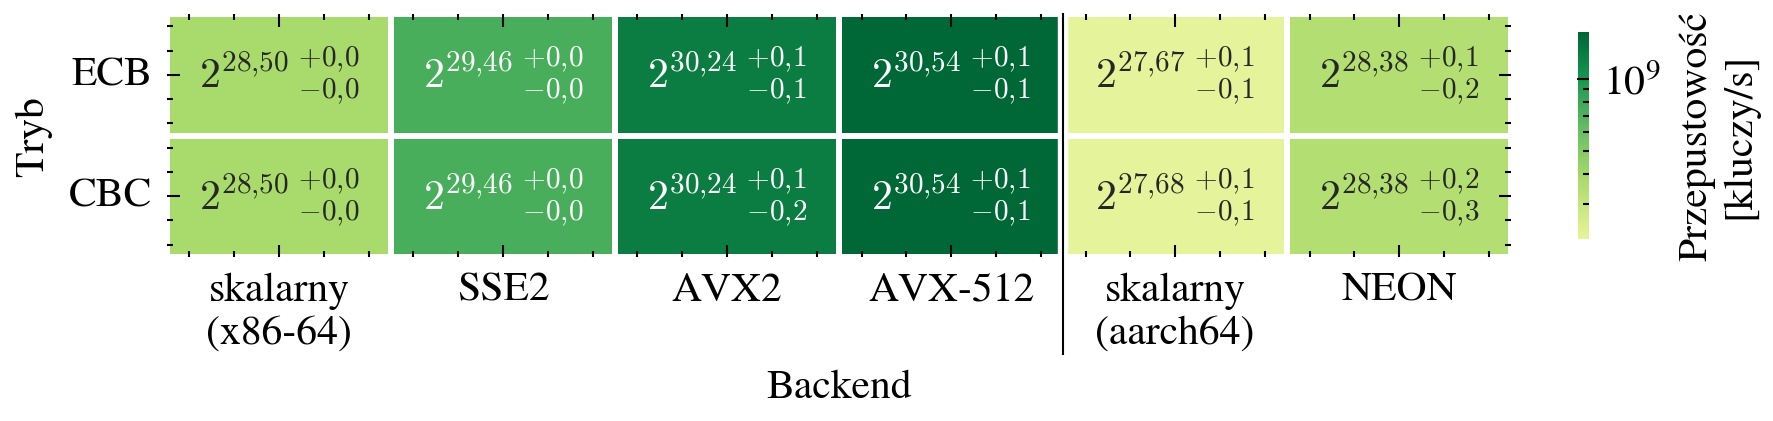

In [35]:
def plot_system_backend_mean(reg_specs, filename):
    val, up, dn, sep = make_system_backend_mean(reg_specs)

    annot = np.empty(val.shape, dtype=object)
    for i in range(val.shape[0]):
        for j in range(val.shape[1]):
            v = val.iloc[i, j]
            u, d_ = up.iloc[i, j], dn.iloc[i, j]
            if pd.isna(v) or v <= 0:
                annot[i, j] = ""
            elif pd.isna(u) or pd.isna(d_):
                annot[i, j] = rf"$2^{{{_pl(np.log2(v), 2)}}}$"
            else:
                annot[i, j] = rf"$2^{{{_pl(np.log2(v), 2)}}}\,^{{+{_pl(u, 1)}}}_{{-{_pl(d_, 1)}}}$"

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT_7), layout='constrained')

        sns.heatmap(
            val,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            norm=LogNorm(vmin=np.nanmin(val.values), vmax=np.nanmax(val.values)),
            annot=annot,
            fmt='',
            linewidths=1.0,
            cbar_kws={'label': 'Przepustowość\n[kluczy/s]', 'shrink': 0.85},
        )

        cbar = ax.collections[0].colorbar
        cbar.ax.yaxis.set_minor_formatter(NullFormatter())

        ax.axvline(x=sep, color='white', linewidth=2.5)
        ax.plot([sep, sep], [0, val.shape[0] + 0.8], color='black', linewidth=0.5,
                clip_on=False, zorder=5)

        ax.set_xlabel('Backend')
        ax.set_ylabel('Tryb')

        plt.setp(ax.get_xticklabels(), rotation=0)
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()


plot_system_backend_mean(
    [
        (system_reg_x86, ['skalarny', 'SSE2', 'AVX2', 'AVX-512'], 'x86-64'),
        (system_reg_aarch64, ['skalarny', 'NEON'], 'aarch64'),
    ],
    'system_pivot_backend_mean_combined.svg',
)

In [36]:
def make_system_mode_mean(reg_specs):
    vals, ups, dns = [], [], []

    for reg_df, backend, label in reg_specs:
        d = reg_df[(reg_df['backend'] == backend) &
                   (reg_df['function'].isin(MODE_ORDER))].copy()

        d['keys'] = d['keys_per_sec']
        d['k_hi'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_low_ns']
        d['k_lo'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_high_ns']

        g = (d.groupby(['function', 'suffix'])[['keys', 'k_lo', 'k_hi']]
             .agg(gmean).reset_index())
        g['up_pct'] = (g['k_hi'] / g['keys'] - 1.0) * 100
        g['dn_pct'] = (1.0 - g['k_lo'] / g['keys']) * 100

        modes = [m for m in MODE_ORDER if m in g['function'].unique()]
        suffixes = sorted(g['suffix'].unique())
        labelmap = {s: str(int(s)) if float(s).is_integer() else str(s) for s in suffixes}
        order = [labelmap[s] for s in suffixes]
        first = order[0]

        def piv(col):
            p = g.pivot(index='function', columns='suffix', values=col).rename(columns=labelmap)
            p.columns.name = None
            p.index.name = None
            p = p.reindex(index=modes, columns=order)
            return p.rename(columns={s: (f"{s}\n({label})" if s == first else s)
                                     for s in p.columns})

        vals.append(piv('keys'))
        ups.append(piv('up_pct'))
        dns.append(piv('dn_pct'))

    sep = vals[0].shape[1]
    return (pd.concat(vals, axis=1), pd.concat(ups, axis=1),
            pd.concat(dns, axis=1), sep)

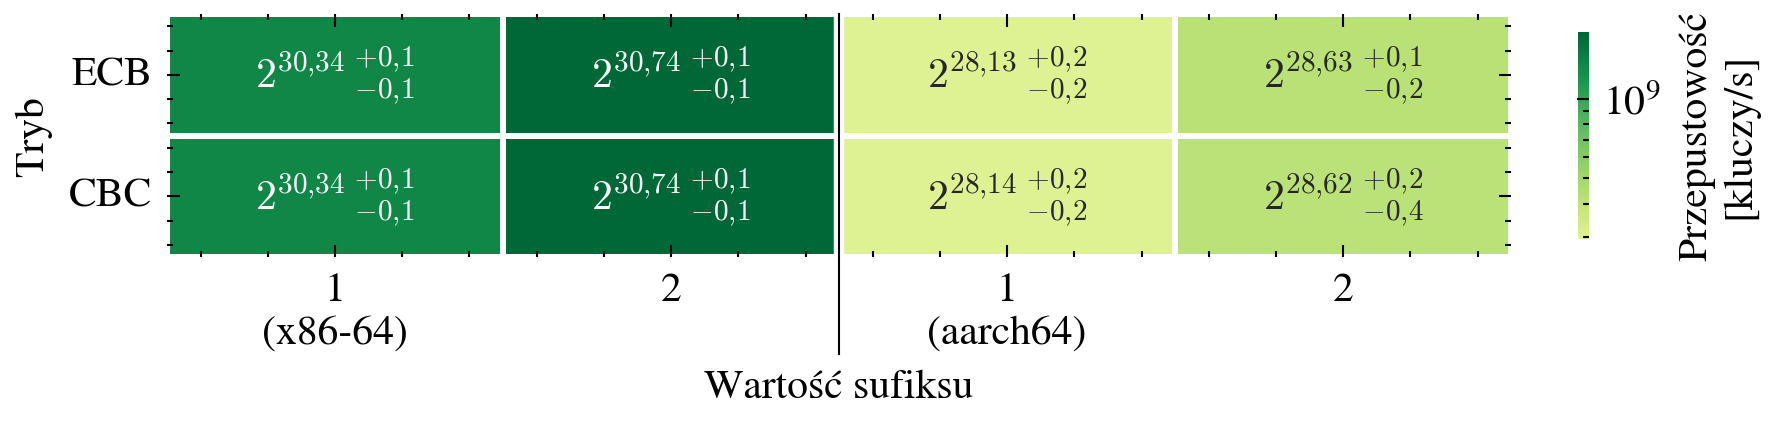

In [37]:
def plot_system_mode_mean(reg_specs, filename):
    val, up, dn, sep = make_system_mode_mean(reg_specs)

    annot = np.empty(val.shape, dtype=object)
    for i in range(val.shape[0]):
        for j in range(val.shape[1]):
            v = val.iloc[i, j]
            u, d_ = up.iloc[i, j], dn.iloc[i, j]
            if pd.isna(v) or v <= 0:
                annot[i, j] = ""
            elif pd.isna(u) or pd.isna(d_):
                annot[i, j] = rf"$2^{{{_pl(np.log2(v), 2)}}}$"
            else:
                annot[i, j] = rf"$2^{{{_pl(np.log2(v), 2)}}}\,^{{+{_pl(u, 1)}}}_{{-{_pl(d_, 1)}}}$"

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT_7), layout='constrained')

        sns.heatmap(
            val,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            norm=LogNorm(vmin=np.nanmin(val.values), vmax=np.nanmax(val.values)),
            annot=annot,
            fmt='',
            linewidths=1.0,
            cbar_kws={'label': 'Przepustowość\n[kluczy/s]', 'shrink': 0.85},
        )

        cbar = ax.collections[0].colorbar
        cbar.ax.yaxis.set_minor_formatter(NullFormatter())

        ax.axvline(x=sep, color='white', linewidth=2.5)
        ax.plot([sep, sep], [0, val.shape[0] + 0.8], color='black', linewidth=0.5,
                clip_on=False, zorder=5)

        ax.set_xlabel('Wartość sufiksu')
        ax.set_ylabel('Tryb')

        plt.setp(ax.get_xticklabels(), rotation=0)
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()


plot_system_mode_mean(
    [
        (system_reg_x86, 'AVX-512', 'x86-64'),
        (system_reg_aarch64, 'NEON', 'aarch64'),
    ],
    'system_pivot_mode_mean_combined.svg',
)

In [38]:
def make_system_mode_combined(reg_specs, suffix):
    vals, ups, dns = [], [], []

    for reg_df, backend, label in reg_specs:
        d = reg_df[(reg_df['backend'] == backend) & (reg_df['suffix'] == suffix)].copy()

        d['keys'] = d['keys_per_sec']
        d['k_hi'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_low_ns']
        d['k_lo'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_high_ns']
        d['up_pct'] = (d['k_hi'] / d['keys'] - 1.0) * 100
        d['dn_pct'] = (1.0 - d['k_lo'] / d['keys']) * 100

        modes = [m for m in MODE_ORDER if m in d['function'].unique()]
        first = modes[0]

        def piv(col):
            p = (d.pivot_table(index='version', columns='function', values=col)
                 .reset_index())
            p.columns.name = None
            p['version'] = pd.Categorical(p['version'], categories=version_order, ordered=True)
            p = p.sort_values('version').reset_index(drop=True)
            p = p.set_index('version')[modes]
            return p.rename(columns={m: (f"{m}\n({label})" if m == first else m)
                                     for m in p.columns})

        vals.append(piv('keys'))
        ups.append(piv('up_pct'))
        dns.append(piv('dn_pct'))

    sep = vals[0].shape[1]
    return (pd.concat(vals, axis=1), pd.concat(ups, axis=1),
            pd.concat(dns, axis=1), sep)

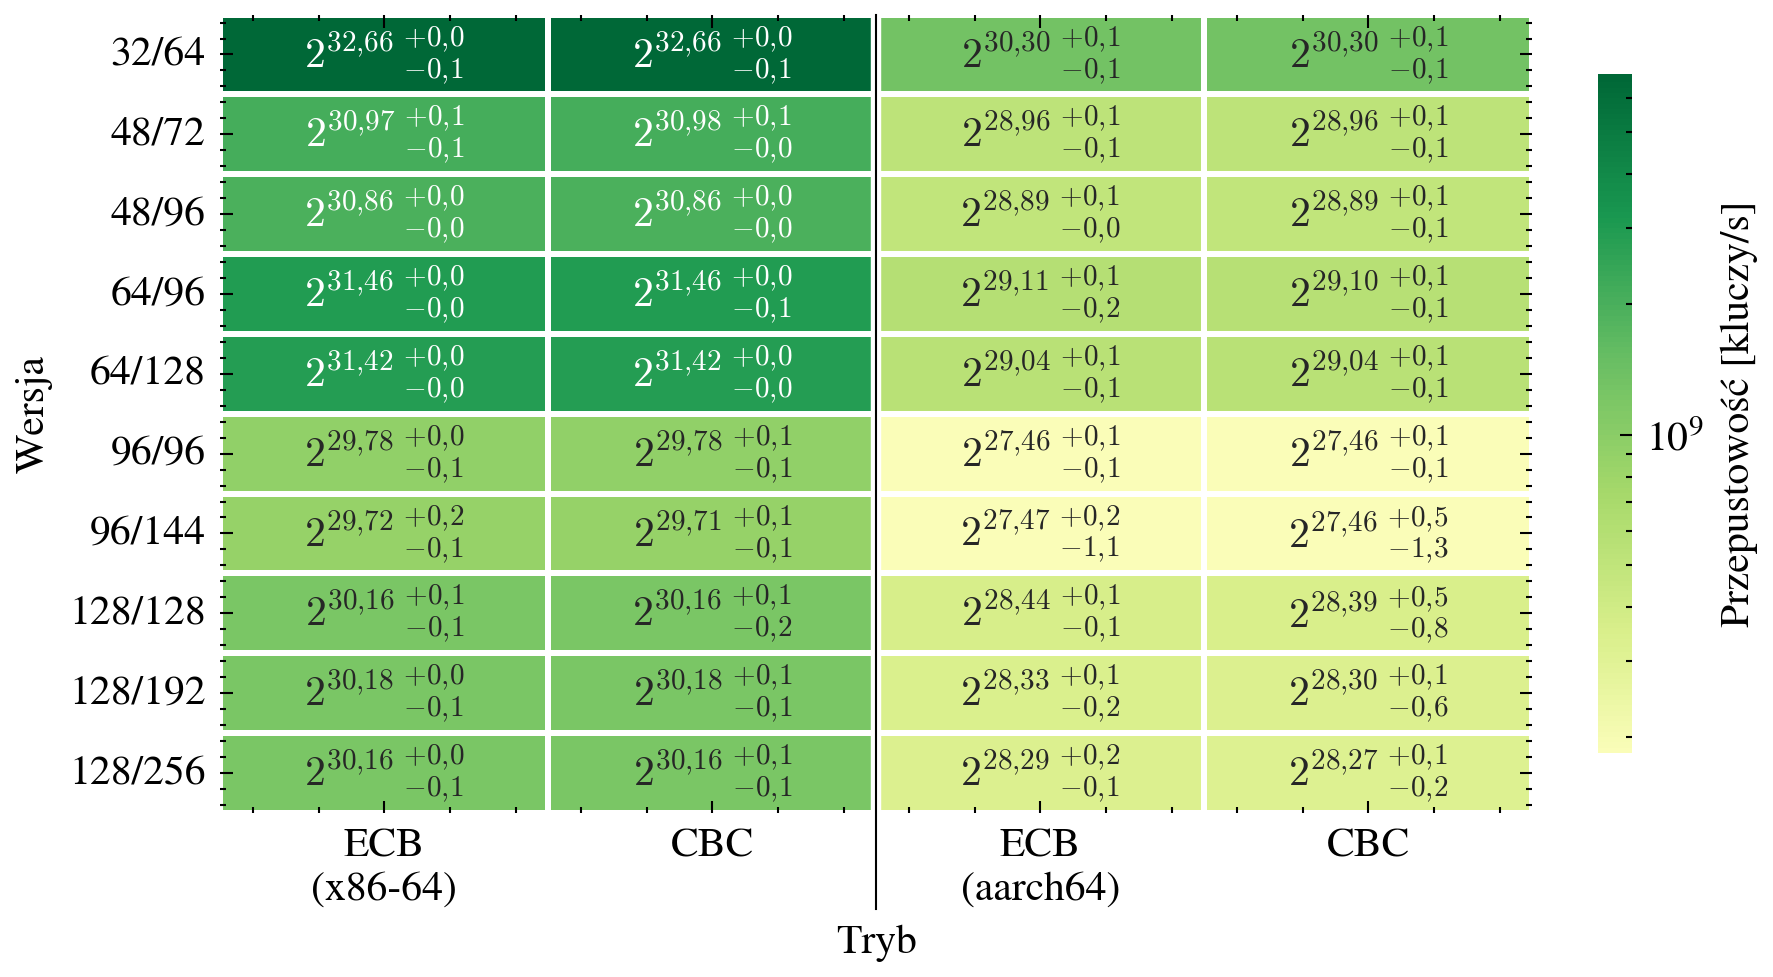

In [39]:
def plot_system_mode_combined(reg_specs, filename, suffix=2):
    val, up, dn, sep = make_system_mode_combined(reg_specs, suffix)

    annot = np.empty(val.shape, dtype=object)
    for i in range(val.shape[0]):
        for j in range(val.shape[1]):
            v = val.iloc[i, j]
            u, d_ = up.iloc[i, j], dn.iloc[i, j]
            if pd.isna(v) or v <= 0:
                annot[i, j] = ""
            elif pd.isna(u) or pd.isna(d_):
                annot[i, j] = rf"$2^{{{_pl(np.log2(v), 2)}}}$"
            else:
                annot[i, j] = rf"$2^{{{_pl(np.log2(v), 2)}}}\,^{{+{_pl(u, 1)}}}_{{-{_pl(d_, 1)}}}$"

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT_3), layout='constrained')

        sns.heatmap(
            val,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            norm=LogNorm(vmin=np.nanmin(val.values), vmax=np.nanmax(val.values)),
            annot=annot,
            fmt='',
            linewidths=1.0,
            cbar_kws={'label': 'Przepustowość [kluczy/s]', 'shrink': 0.85},
        )

        cbar = ax.collections[0].colorbar
        cbar.ax.yaxis.set_minor_formatter(NullFormatter())

        ax.axvline(x=sep, color='white', linewidth=2.5)
        ax.plot([sep, sep], [0, val.shape[0] + 1.2], color='black', linewidth=0.5,
                clip_on=False, zorder=5)

        ax.set_xlabel('Tryb')
        ax.set_ylabel('Wersja')

        plt.setp(ax.get_xticklabels(), rotation=0)
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()


plot_system_mode_combined(
    [
        (system_reg_x86, 'AVX-512', 'x86-64'),
        (system_reg_aarch64, 'NEON', 'aarch64'),
    ],
    'system_pivot_mode_single_combined.svg',
)

In [40]:
def make_system_backend_speedup(reg_specs, suffix=2):
    all_vals, all_ups, all_dns = [], [], []

    for reg_df, backends, label in reg_specs:
        d = reg_df[reg_df['suffix'] == suffix].copy()
        d['k_hi'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_low_ns']
        d['k_lo'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_high_ns']

        sc = d[d['backend'] == 'skalarny'].set_index(['version', 'function'])

        first = True
        for backend in backends:
            b = d[d['backend'] == backend].set_index(['version', 'function'])
            b['speedup'] = b['keys_per_sec'] / sc['keys_per_sec']
            b['sp_hi'] = b['k_hi'] / sc['k_lo']
            b['sp_lo'] = b['k_lo'] / sc['k_hi']
            b['log_sp'] = np.log(b['speedup'])
            b['log_hi'] = np.log(b['sp_hi'])
            b['log_lo'] = np.log(b['sp_lo'])
            b = b.reset_index()

            def geomean_col(col, b=b):
                p = b.pivot_table(index='version', columns='function', values=col)
                p.index = pd.Categorical(p.index, categories=version_order, ordered=True)
                return np.exp(p.sort_index().mean(axis=1, skipna=True))

            gm_sp = geomean_col('log_sp')
            gm_hi = geomean_col('log_hi')
            gm_lo = geomean_col('log_lo')

            col_name = f"{backend}\n({label})" if first else backend
            first = False

            all_vals.append(gm_sp.rename(col_name))
            all_ups.append((gm_hi / gm_sp - 1.0).mul(100).rename(col_name))
            all_dns.append((1.0 - gm_lo / gm_sp).mul(100).rename(col_name))

    sep = len(reg_specs[0][1])
    val = pd.concat(all_vals, axis=1)
    up = pd.concat(all_ups, axis=1)
    dn = pd.concat(all_dns, axis=1)
    return val, up, dn, sep


def plot_system_backend_speedup(reg_specs, filename, suffix=2):
    val, up, dn, sep = make_system_backend_speedup(reg_specs, suffix)

    annot = np.empty(val.shape, dtype=object)
    for i in range(val.shape[0]):
        for j in range(val.shape[1]):
            v = val.iloc[i, j]
            u, d_ = up.iloc[i, j], dn.iloc[i, j]
            if pd.isna(v):
                annot[i, j] = ""
            elif pd.isna(u) or pd.isna(d_):
                annot[i, j] = rf"${_pl(v, 2)}$"
            else:
                annot[i, j] = rf"${_pl(v, 1)}^{{+{_pl(u, 1)}}}_{{-{_pl(d_, 1)}}}$"

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT_3), layout='constrained')

        sns.heatmap(
            val,
            ax=ax,
            annot=annot,
            fmt='',
            cmap='RdYlGn',
            center=1,
            linewidths=1.0,
            cbar_kws={'label': 'Krotność przyspieszenia', 'shrink': 0.85},
        )

        ax.axvline(x=sep, color='white', linewidth=2.5)
        ax.plot([sep, sep], [0, val.shape[0] + 1.2], color='black', linewidth=0.5,
                clip_on=False, zorder=5)

        ax.set_xlabel('Backend')
        ax.set_ylabel('Wersja')

        plt.setp(ax.get_xticklabels(), rotation=0)
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()

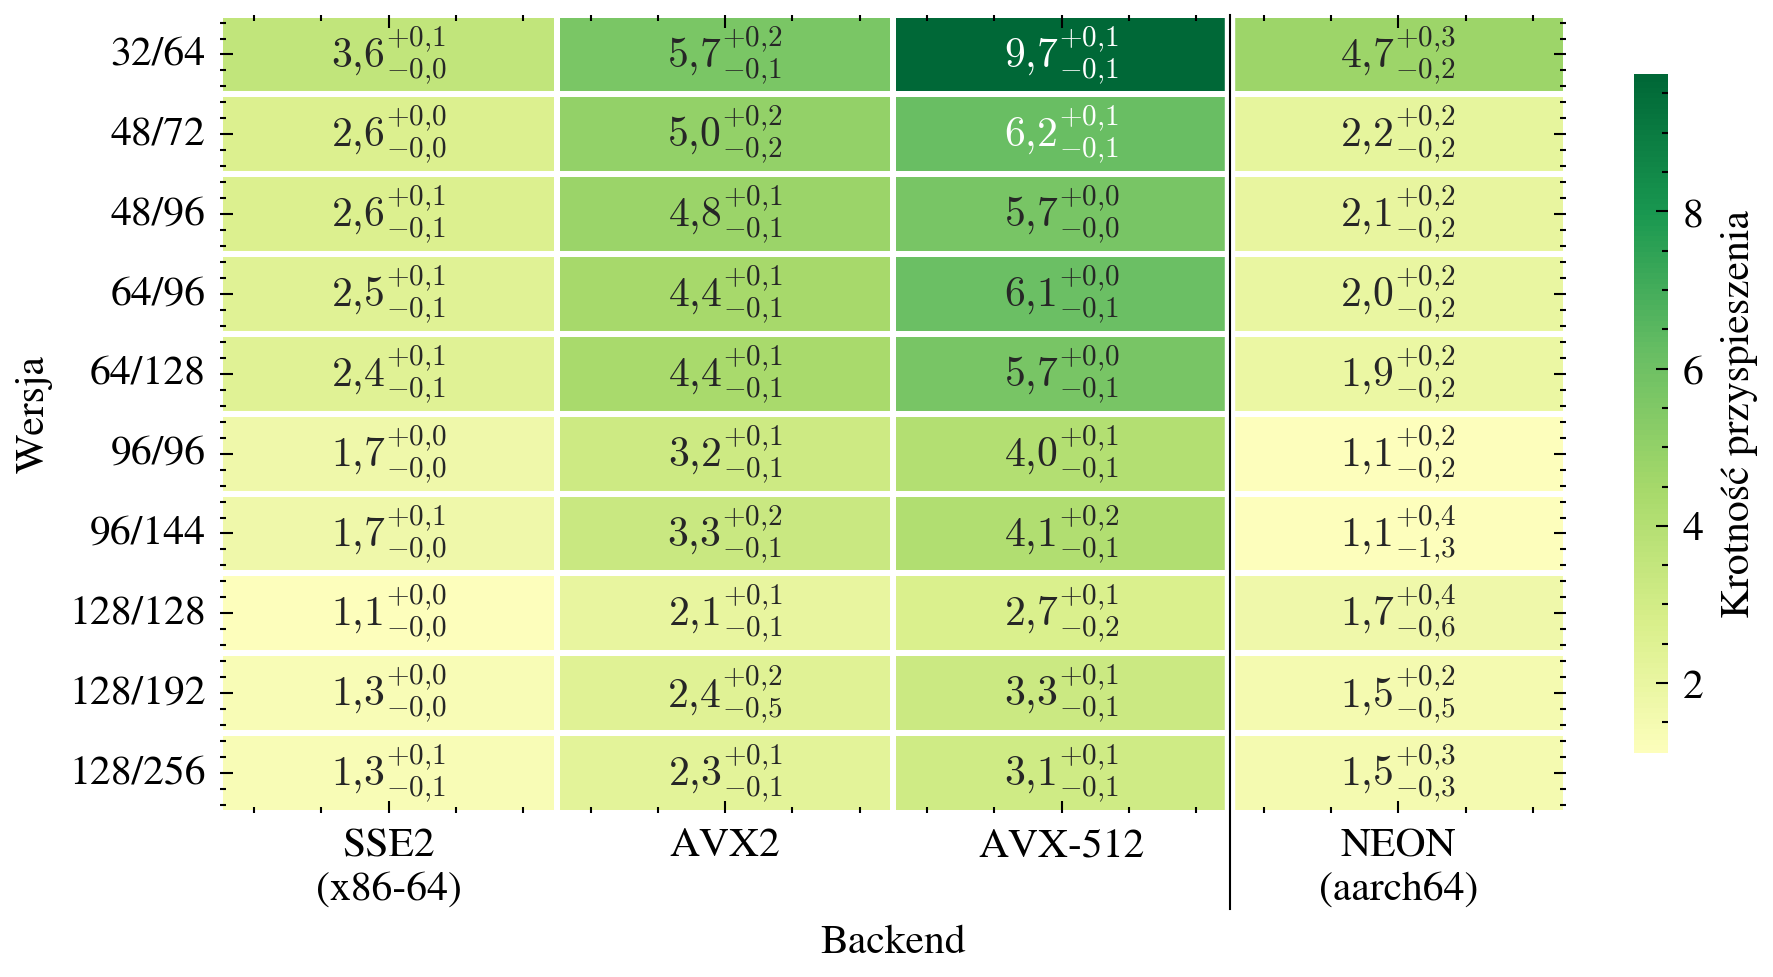

In [41]:
plot_system_backend_speedup(
    [
        (system_reg_x86, ['SSE2', 'AVX2', 'AVX-512'], 'x86-64'),
        (system_reg_aarch64, ['NEON'], 'aarch64'),
    ],
    'system_backend_speedup.svg',
)

In [42]:
tezcan_data = {
    "GPU": ["MX 250", "GTX 860M", "GTX 970", "RTX 2070 Super", "RTX 4090"],
    "32/64": [30.56, 30.53, 32.12, 33.99, 36.20],
    "48/72": [30.72, 30.72, 32.43, 34.27, 36.47],
    "64/96": [31.43, 31.30, 32.99, 34.49, 36.72],
    "128/128": [29.93, 29.86, 31.38, 32.97, 35.30],
}

tezcan = pd.DataFrame(tezcan_data).set_index("GPU")

In [43]:
def fmt_pow2_only(a):
    if pd.isna(a):
        return "--"
    return rf"\(2^{{{_pl(a, 2)}}}\)"


def make_our_tezcan(reg_specs, suffix=2, mode='ECB'):
    fmt_rows, log2_rows = {}, {}
    for reg_df, backend, label in reg_specs:
        d = reg_df[(reg_df['backend'] == backend) &
                   (reg_df['function'] == mode) &
                   (reg_df['suffix'] == suffix)].copy()
        d['k_hi'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_low_ns']
        d['k_lo'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_high_ns']
        d['cell'] = [fmt_pow2_pct(x, lo, hi)
                     for x, lo, hi in zip(d['keys_per_sec'], d['k_lo'], d['k_hi'])]
        d['log2'] = np.log2(d['keys_per_sec'])
        fmt_rows[label] = d.set_index('version')['cell'].reindex(tezcan.columns)
        log2_rows[label] = d.set_index('version')['log2'].reindex(tezcan.columns)
    return pd.DataFrame(fmt_rows).T, pd.DataFrame(log2_rows).T


our_latex, our_log2 = make_our_tezcan([
    (system_reg_x86, 'AVX-512', 'AVX-512 (x86-64)'),
    (system_reg_aarch64, 'NEON', 'NEON (aarch64)'),
])

our_latex = our_latex.loc[our_log2.mean(axis=1).sort_values().index]

tezcan_fmt = (tezcan.loc[tezcan.mean(axis=1).sort_values().index]
              .apply(lambda col: col.map(fmt_pow2_only)))

our_latex

,32/64,48/72,64/96,128/128
NEON (aarch64),"\(2^{30{,}30}\,^{+0{,}1\%}_{-0{,}1\%}\)","\(2^{28{,}96}\,^{+0{,}1\%}_{-0{,}1\%}\)","\(2^{29{,}11}\,^{+0{,}1\%}_{-0{,}2\%}\)","\(2^{28{,}44}\,^{+0{,}1\%}_{-0{,}1\%}\)"
AVX-512 (x86-64),"\(2^{32{,}66}\,^{+0{,}0\%}_{-0{,}1\%}\)","\(2^{30{,}97}\,^{+0{,}1\%}_{-0{,}1\%}\)","\(2^{31{,}46}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{30{,}16}\,^{+0{,}1\%}_{-0{,}1\%}\)"


In [44]:
our_latex.to_csv("../csv/own_results.csv", sep=';')
our_latex

,32/64,48/72,64/96,128/128
NEON (aarch64),"\(2^{30{,}30}\,^{+0{,}1\%}_{-0{,}1\%}\)","\(2^{28{,}96}\,^{+0{,}1\%}_{-0{,}1\%}\)","\(2^{29{,}11}\,^{+0{,}1\%}_{-0{,}2\%}\)","\(2^{28{,}44}\,^{+0{,}1\%}_{-0{,}1\%}\)"
AVX-512 (x86-64),"\(2^{32{,}66}\,^{+0{,}0\%}_{-0{,}1\%}\)","\(2^{30{,}97}\,^{+0{,}1\%}_{-0{,}1\%}\)","\(2^{31{,}46}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{30{,}16}\,^{+0{,}1\%}_{-0{,}1\%}\)"


In [45]:
tezcan_fmt.to_csv("../csv/tezcan_results.csv", sep=';')
tezcan_fmt

,32/64,48/72,64/96,128/128
GPU,,,,
GTX 860M,"\(2^{30{,}53}\)","\(2^{30{,}72}\)","\(2^{31{,}30}\)","\(2^{29{,}86}\)"
MX 250,"\(2^{30{,}56}\)","\(2^{30{,}72}\)","\(2^{31{,}43}\)","\(2^{29{,}93}\)"
GTX 970,"\(2^{32{,}12}\)","\(2^{32{,}43}\)","\(2^{32{,}99}\)","\(2^{31{,}38}\)"
RTX 2070 Super,"\(2^{33{,}99}\)","\(2^{34{,}27}\)","\(2^{34{,}49}\)","\(2^{32{,}97}\)"
RTX 4090,"\(2^{36{,}20}\)","\(2^{36{,}47}\)","\(2^{36{,}72}\)","\(2^{35{,}30}\)"


In [46]:
tezcan_fmt_all = tezcan.apply(lambda col: col.map(fmt_pow2_only))
log2_all = pd.concat([tezcan, our_log2])
fmt_all = pd.concat([tezcan_fmt_all, our_latex])

combined_latex = fmt_all.loc[log2_all.mean(axis=1).sort_values().index]
combined_latex.index.name = tezcan.index.name
combined_latex.to_csv("../csv/combined_results.csv", sep=';')
combined_latex

,32/64,48/72,64/96,128/128
GPU,,,,
NEON (aarch64),"\(2^{30{,}30}\,^{+0{,}1\%}_{-0{,}1\%}\)","\(2^{28{,}96}\,^{+0{,}1\%}_{-0{,}1\%}\)","\(2^{29{,}11}\,^{+0{,}1\%}_{-0{,}2\%}\)","\(2^{28{,}44}\,^{+0{,}1\%}_{-0{,}1\%}\)"
GTX 860M,"\(2^{30{,}53}\)","\(2^{30{,}72}\)","\(2^{31{,}30}\)","\(2^{29{,}86}\)"
MX 250,"\(2^{30{,}56}\)","\(2^{30{,}72}\)","\(2^{31{,}43}\)","\(2^{29{,}93}\)"
AVX-512 (x86-64),"\(2^{32{,}66}\,^{+0{,}0\%}_{-0{,}1\%}\)","\(2^{30{,}97}\,^{+0{,}1\%}_{-0{,}1\%}\)","\(2^{31{,}46}\,^{+0{,}0\%}_{-0{,}0\%}\)","\(2^{30{,}16}\,^{+0{,}1\%}_{-0{,}1\%}\)"
GTX 970,"\(2^{32{,}12}\)","\(2^{32{,}43}\)","\(2^{32{,}99}\)","\(2^{31{,}38}\)"
RTX 2070 Super,"\(2^{33{,}99}\)","\(2^{34{,}27}\)","\(2^{34{,}49}\)","\(2^{32{,}97}\)"
RTX 4090,"\(2^{36{,}20}\)","\(2^{36{,}47}\)","\(2^{36{,}72}\)","\(2^{35{,}30}\)"
